# Claris: Histopathology Cancer Detector

This project was realized for Expo-Science hosted by Hydro-Quebec.

## Introduction

Many healthcare professionals are under great pressure with the current situation of Quebec's healthcare industry. A severe lack of personnel is a prominent issue, and the efficiency in cancer diagnosis process was worsened by this problem. It is not always easy to detect cancer in images. This project aims to develop a deep learning model that can detect histopathologic cancer in images, in order to ease the process of detection and pressure on the healthcare industry.

---

## Dataset

https://www.kaggle.com/competitions/histopathologic-cancer-detection/data 

This dataset of histopathologic scans of lymph node sections is a modified version of the PCAM (PatchCamelyon) dataset.

> 
    The PatchCamelyon benchmark (PCAM) consists of 327.680 color images (96 x 96px) extracted from histopathologic scans of lymph node sections. Each image is annoted with a binary label indicating presence of metastatic tissue.
    Fundamental machine learning advancements are predominantly evaluated on straight-forward natural-image classification datasets and medical imaging is becoming one of the major applications of ML and thus deserves a spot on the list of go-to ML datasets. Both to challenge future work, and to steer developments into directions that are beneficial for this domain.


## Model

The model used in this project is Resnet-50, a type of Convolutional Neural Network (CNN) for precision purposes. The CNN is trained on the dataset using the categorical cross-entropy loss function. The model will be able to classify the images into one of the following categories: benign or malignant.

## Implementation

The implementation of the model is done with Jupyter Notebook using the Pytorch library. The model is trained on Kaggle duo-T4 GPU using the Adam optimizer. 
  
## Accuracy
The model achieved a peak accuracy of around 97.5% after 6 epochs.

## Sources
Thanks to many Kaggle competitions, datasets and notebooks for inspiration.

### 1) Imports and configuration

In [1]:
# Import useful libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns


#### Setting up the environment
Using Kaggle's Nvidia GPU 

In [2]:
# Device -> Nvidia GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Use GPU cuda if available
print('Using device:', DEVICE)

# Config for images
IMG_SIZE = 96
BATCH_SIZE = 64
NUM_WORKERS = 2

Using device: cuda


### 2) Data transformations
Diversify the training data by augmenting the images with random rotations, flips, and translations.

In [3]:
# Train data transformations
#  - Augmented to increase diversity of the dataset
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),            # Ensure consistent size
    transforms.RandomHorizontalFlip(),                  # Random flips (augmentation)
    transforms.RandomVerticalFlip(),                    # Random flips  (augmentation)
    transforms.RandomRotation(20),                      # Random rotations (augmentation)
    transforms.ToTensor(),                              # Convert to tensor
    transforms.Normalize(                               # Standardize pixel values
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

# Test data transformations (no augmentation or randomness)
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 3) Data loading helper class


In [4]:
class Dataset(Dataset):
    """
    Dataset for Kaggle Histopathologic Cancer Detection (based on PCAM)
    Uses .tif images + train_labels.csv
    """

    def __init__(self, img_dir, csv_path, transform=None):
        self.img_dir = img_dir
        self.transform = transform
    
        self.df = pd.read_csv(csv_path) # train_labels.csv

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx, 0]          # image id
        label  = int(self.df.iloc[idx, 1])     # 0 or 1 (cancer or not)

        # Load image and convert pixel data to RGB values
        img_path = os.path.join(self.img_dir, img_id + ".tif")
        image = Image.open(img_path).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, label


### 4) Load PCam dataset


In [5]:
# Kaggle directory (PCam)
BASE_DIR = "/kaggle/input/competitions/histopathologic-cancer-detection/"

TRAIN_DIR = BASE_DIR + "train"
CSV_PATH = BASE_DIR + "train_labels.csv"

# Read in the CSV file
df = pd.read_csv(CSV_PATH)

# Split into train and validation datasets
train_df, val_df = train_test_split(
    df,
    test_size=0.2,          # 20% of the data will be used for validation
    stratify=df["label"],   # Ensure that the validation set has similar distribution to the training set
    random_state=42
)

# Save the split datasets to CSV files
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)


#### Data loaders


In [6]:
# Batch per step for parallel training
BATCH_SIZE = 128

train_dataset = Dataset(
    TRAIN_DIR, "train_split.csv", train_tfms
)

val_dataset = Dataset(
    TRAIN_DIR, "val_split.csv", val_tfms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True, # faster GPU data transfer
    persistent_workers=True, # keep warm state for >1 epoch
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    persistent_workers=True,
    num_workers=4
)

### 5) Loading ResNet-50 model
The model has been pre-trained on ImageNet (Transfer learning). <br>
Hence, the model already knows how to detect edges, textures, patterns, colors, etc.


In [7]:
# Load pretrained Resnet50 from torchvision
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Replace the classifier layer (fully connected layer)
# ResNet outputs 2048 features → we need 2 classes for benign / malignant
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Wrap for multi-GPU
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = torch.nn.DataParallel(model) # parallel computing
    
model = model.to(DEVICE)

# If model exists, load it
if os.path.exists("./claris_resnet-50.pth"):
    model.load_state_dict(torch.load("./claris_resnet-50.pth"))
    print(f"Successfully loaded saved model ResNet-50")
else:
    print("No saved model found. Training from scratch.")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


Using 2 GPUs!
No saved model found. Training from scratch.


#### Loss function and optimizer

In [8]:
# Class imbalance handling
class_weights = torch.tensor([1.0, 1.5]).to(DEVICE)

# Binary classification
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Prevent underflow (~0 gradient rounded to 0)
scaler = torch.amp.GradScaler() 

### 6) Training the model


In [9]:
def train_one_epoch(model, loader):
    
    model.train()  # enable training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    loop = tqdm(loader, total=len(train_loader), desc="Training")

    for images, labels in loop:
        # Move data to device (GPU)
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # Reset gradients
        optimizer.zero_grad()
        
        # Mixed precision training for faster training
        # COMPARE RESULTS AND PENALIZE LOSS
        with torch.amp.autocast("cuda"):
            # Forward pass (prediction results)
            outputs = model(images)
            # Compute loss
            loss = criterion(outputs, labels)

        # Backpropagation (how should each weight change to make the loss smaller?)
        scaler.scale(loss).backward() # loss.backward()

        # Update weights for real
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        
        # Compute accuracy
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        train_acc = correct / total
        
        # Update progress bar
        loop.set_postfix(loss=running_loss / (loop.n+1))
        
    print(f"Trained {correct} correct out of {total}")

    return running_loss / len(loader), train_acc


#### Validation

In [10]:
def validate(model, loader):
    model.eval()  # evaluation mode
    correct = 0
    total = 0
    
    # Lists to store all predicitons and actual labels for the entire epoch
    all_predictions = []
    all_labels = []

    # Disable gradients in inference mode
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False): # Progress bar
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Keep track of the total number of correct predictions and total predictions
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            # Move tensors back to CPU and add to our lists
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Calculate metrics
    acc = accuracy_score(all_labels, all_predictions)
    prec = precision_score(all_labels, all_predictions, zero_division=0)
    rec = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    cm = confusion_matrix(all_labels, all_predictions)

    # Print out the results
    print(f"Validation -> Acc: {acc*100:.2f}% | Precision: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1: {f1:.4f}")
    
    # Plot the Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Benign (0)', 'Malignant (1)'], 
                yticklabels=['Benign (0)', 'Malignant (1)'])
    plt.ylabel('Réelle')
    plt.xlabel('Prédite')
    plt.title('Matrice de confusion')
    plt.show()

    return acc



### 7) Visualizing prediction results


In [11]:
# Plotting for visualization

def plot_validation_accuracy(val_history):
    epochs = range(1, len(val_history) + 1)
    
    plt.figure(figsize=(10, 6))
    # Plot only the validation data
    plt.plot(epochs, val_history, marker='s', linestyle='-', color='r', label='Exactitude de validation')
    
    plt.title("Évolution de l'exactitude de ResNet-50 en fonction des epochs (Validation)")
    plt.xlabel('Epochs')
    plt.ylabel('Exactitude (%)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    
def plot_training_accuracy(train_history):
    epochs = range(1, len(train_history) + 1)
    
    plt.figure(figsize=(10, 6))
    # Plot only the training data
    plt.plot(epochs, train_history, marker='s', linestyle='-', color='b', label='Exactitude d\'entraînement')
    
    plt.title("Évolution de l'exactitude de ResNet-50 en fonction des epochs (Entraînement)")
    plt.xlabel('Epochs')
    plt.ylabel('Exactitude (%)')
    plt.legend()
    plt.grid(True)
    plt.show()



Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 160279 correct out of 176020


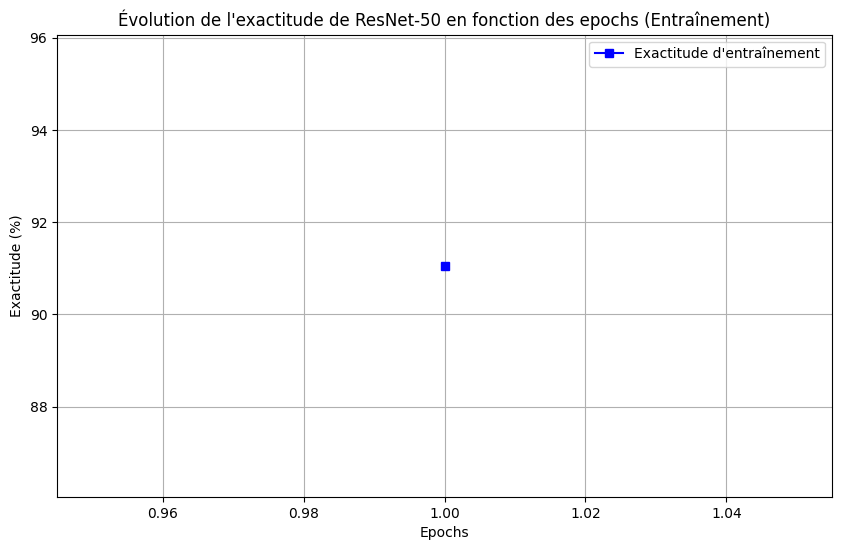

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 95.33% | Precision: 93.58% | Recall: 94.98% | F1: 0.9427


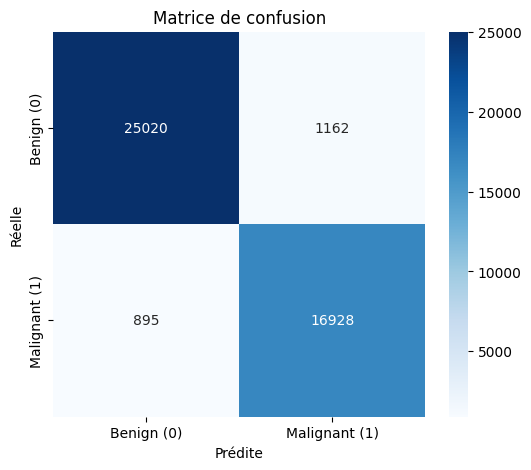

Epoch [1/15] Train Loss: 0.2245 | Train Acc: 91.06% | Val Acc: 95.33% 


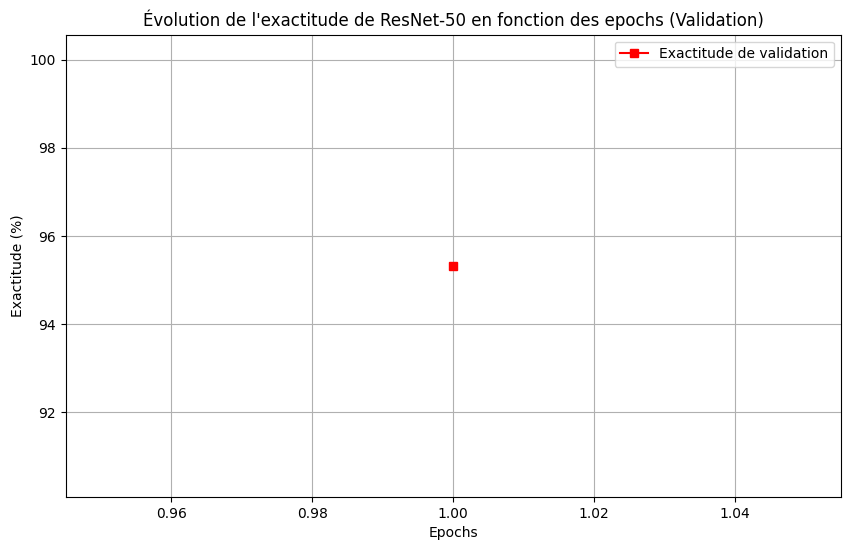

✓ Model saved with 95.33% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 166716 correct out of 176020


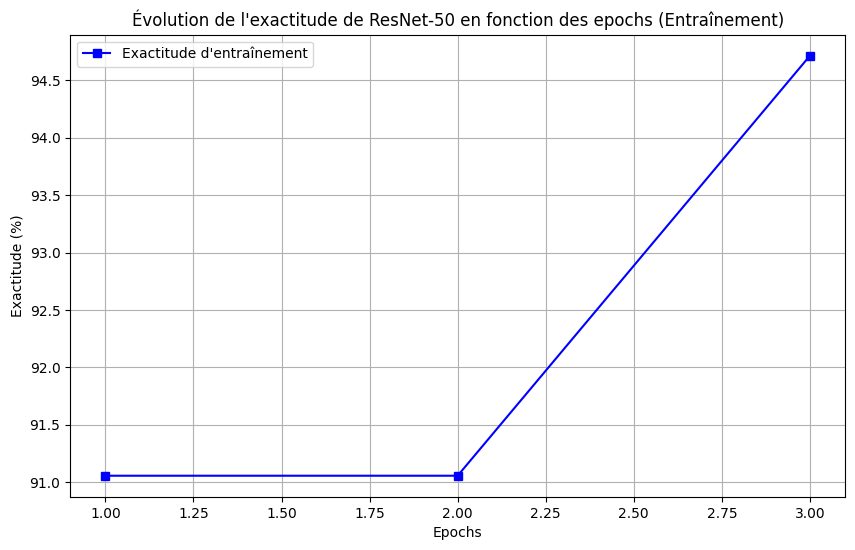

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 96.32% | Precision: 95.36% | Recall: 95.57% | F1: 0.9547


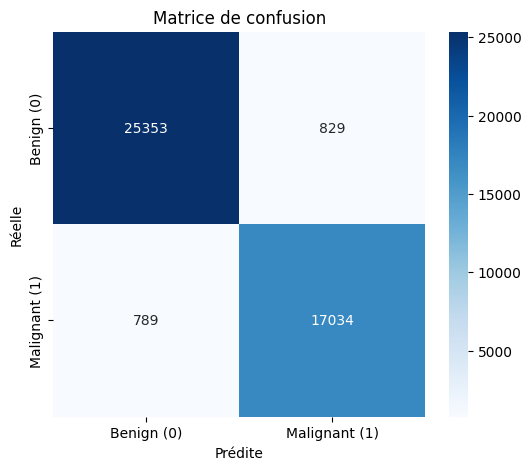

Epoch [2/15] Train Loss: 0.1441 | Train Acc: 94.71% | Val Acc: 96.32% 


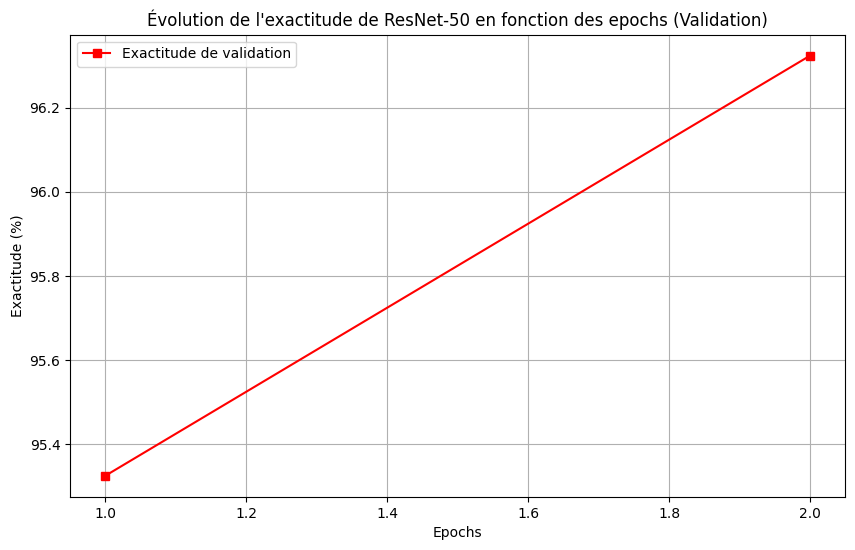

✓ Model saved with 96.32% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 168573 correct out of 176020


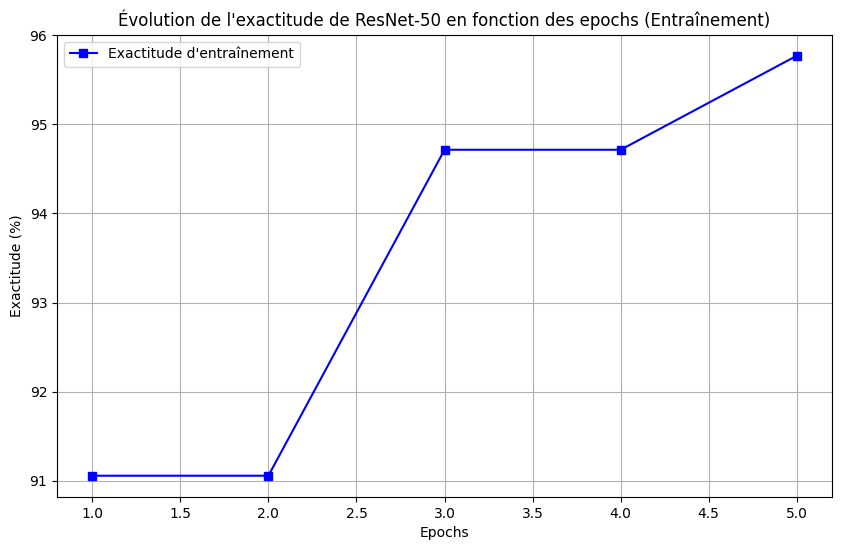

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 96.45% | Precision: 94.08% | Recall: 97.36% | F1: 0.9569


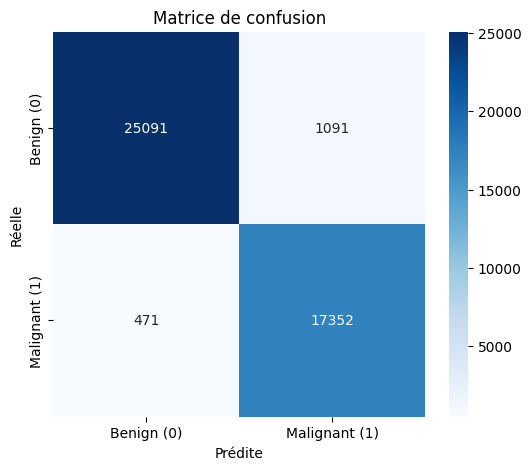

Epoch [3/15] Train Loss: 0.1172 | Train Acc: 95.77% | Val Acc: 96.45% 


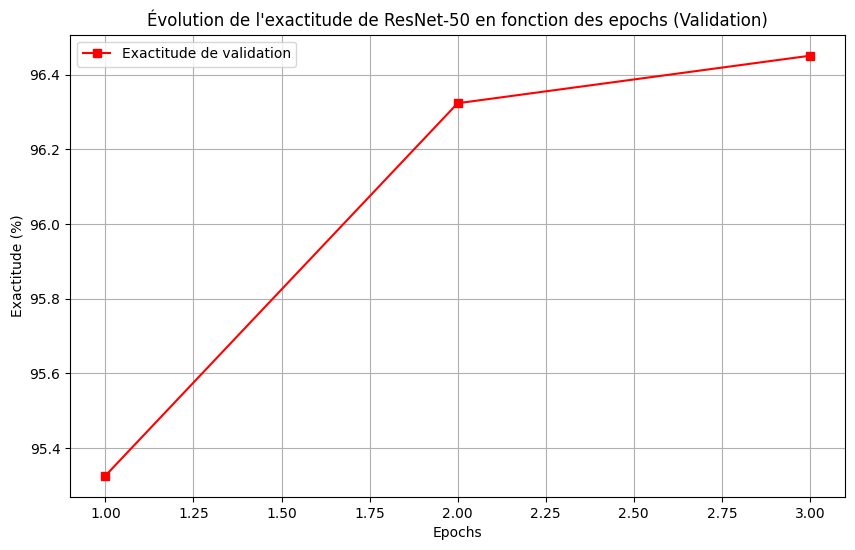

✓ Model saved with 96.45% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 169578 correct out of 176020


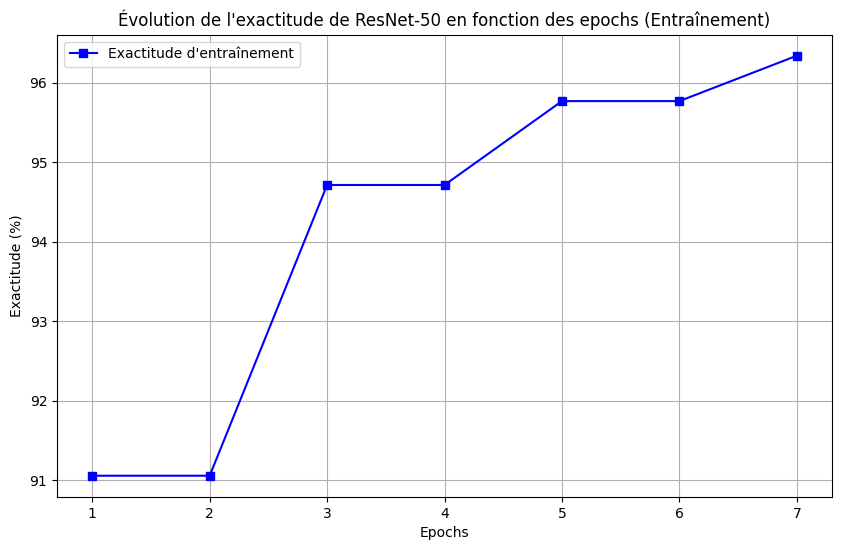

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 96.63% | Precision: 94.27% | Recall: 97.62% | F1: 0.9592


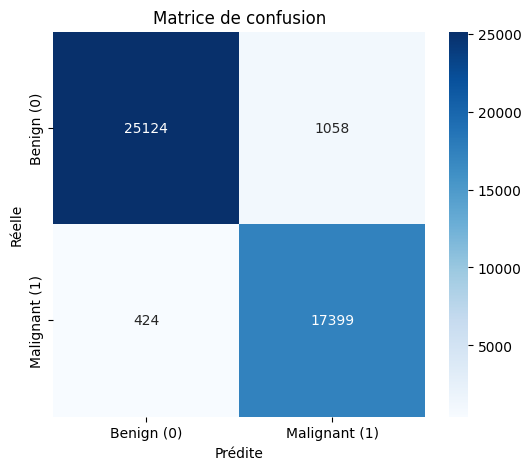

Epoch [4/15] Train Loss: 0.1016 | Train Acc: 96.34% | Val Acc: 96.63% 


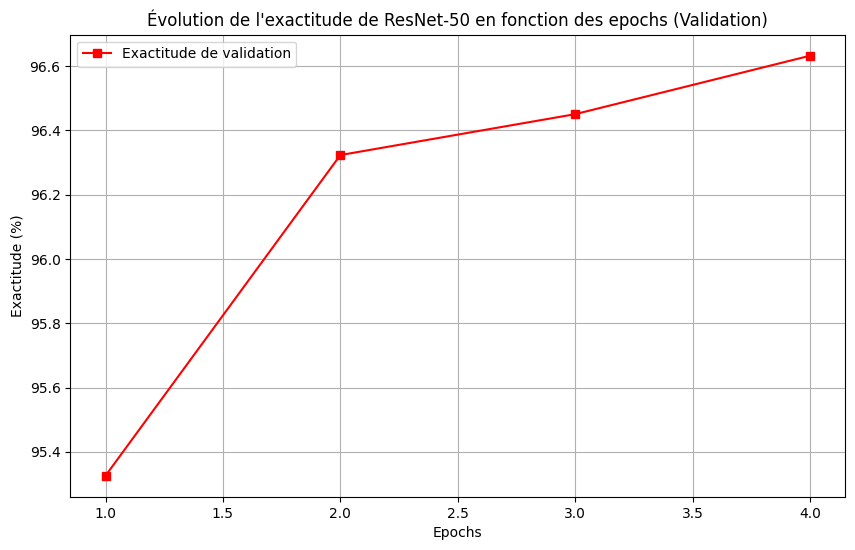

✓ Model saved with 96.63% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 170444 correct out of 176020


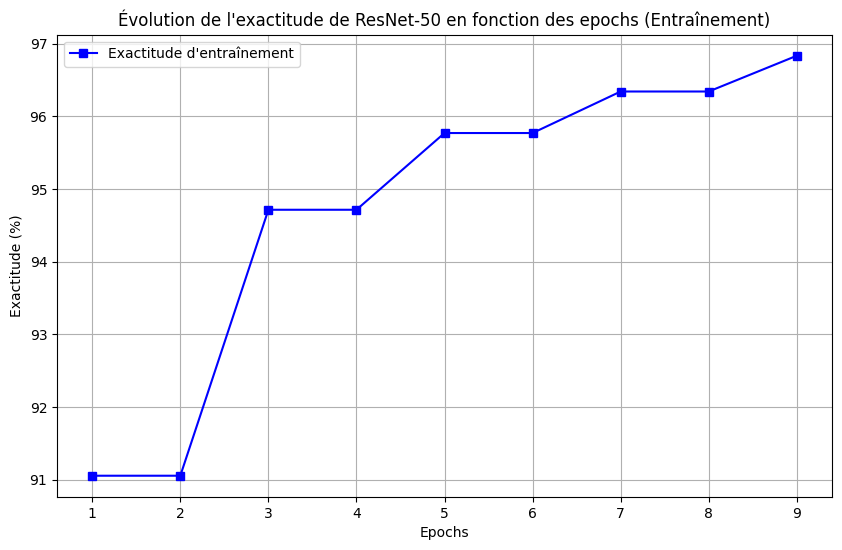

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.28% | Precision: 96.05% | Recall: 97.27% | F1: 0.9666


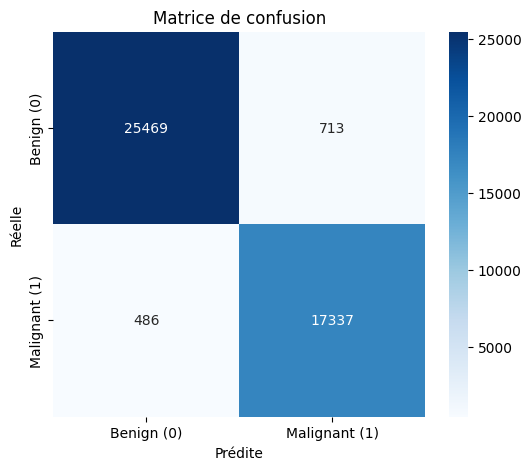

Epoch [5/15] Train Loss: 0.0893 | Train Acc: 96.83% | Val Acc: 97.28% 


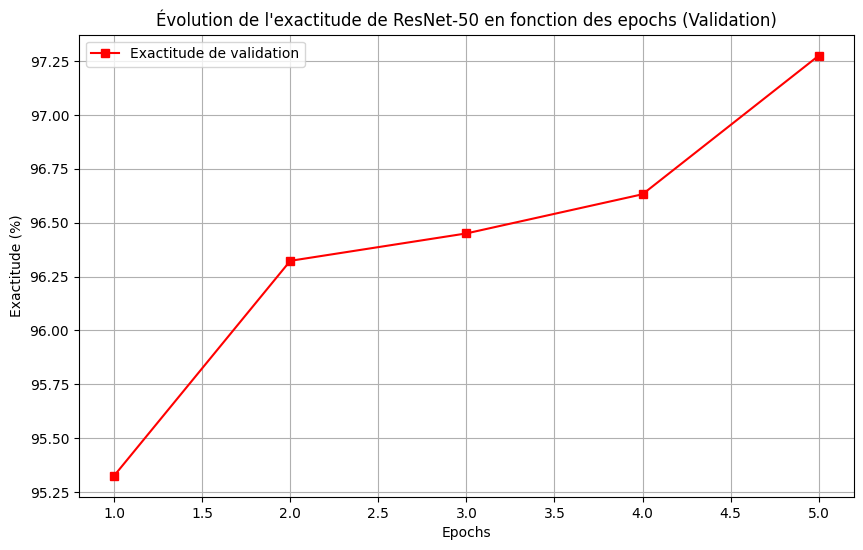

✓ Model saved with 97.28% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 170949 correct out of 176020


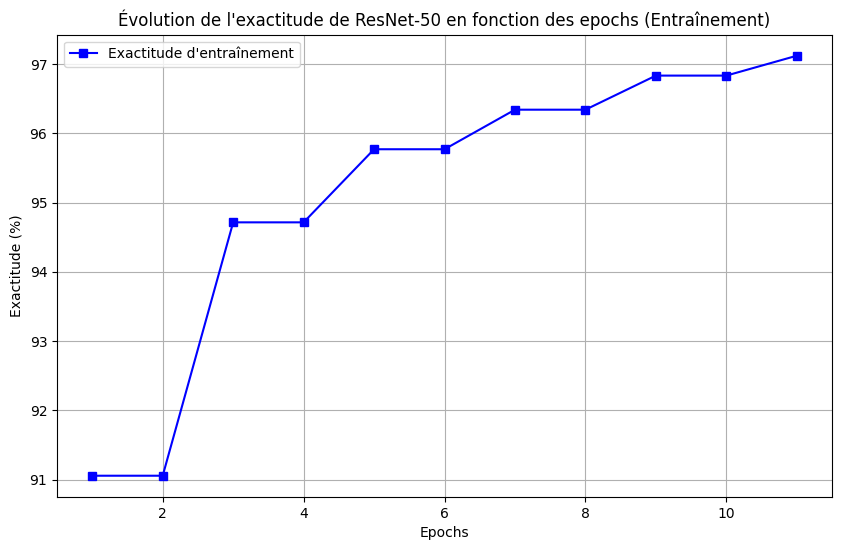

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.01% | Precision: 94.81% | Recall: 97.97% | F1: 0.9637


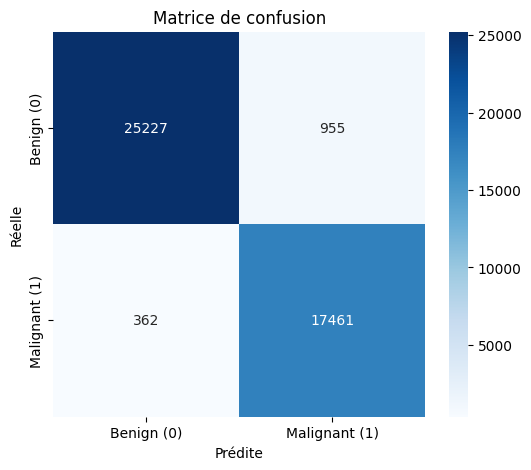

Epoch [6/15] Train Loss: 0.0810 | Train Acc: 97.12% | Val Acc: 97.01% 


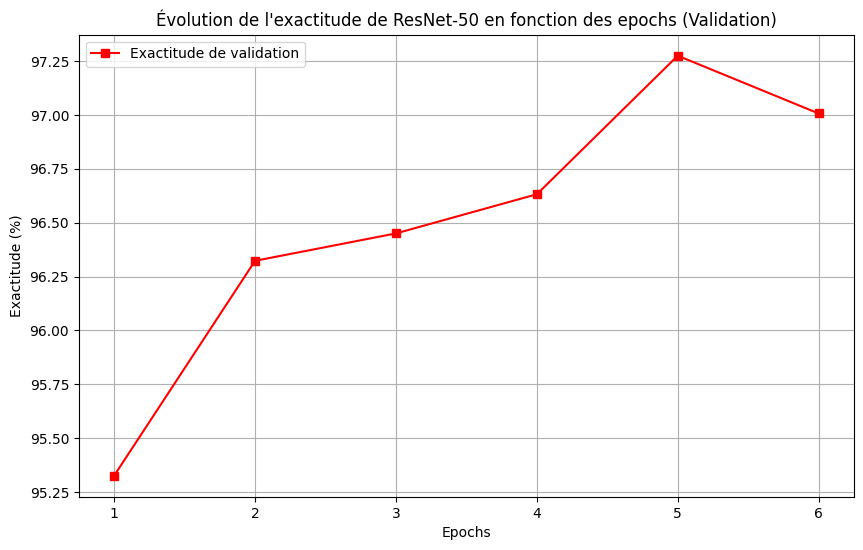

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 171418 correct out of 176020


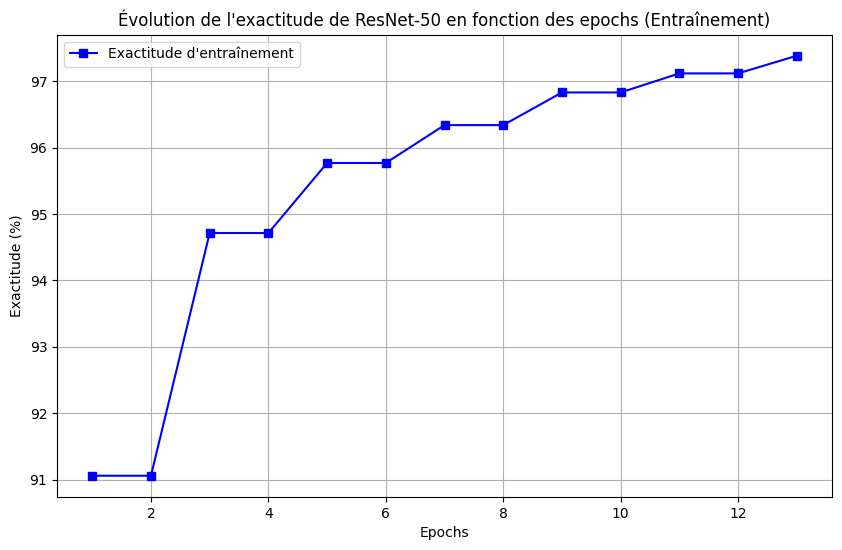

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.38% | Precision: 95.88% | Recall: 97.74% | F1: 0.9680


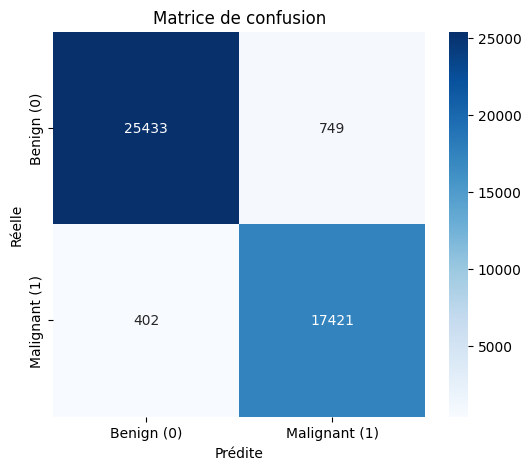

Epoch [7/15] Train Loss: 0.0739 | Train Acc: 97.39% | Val Acc: 97.38% 


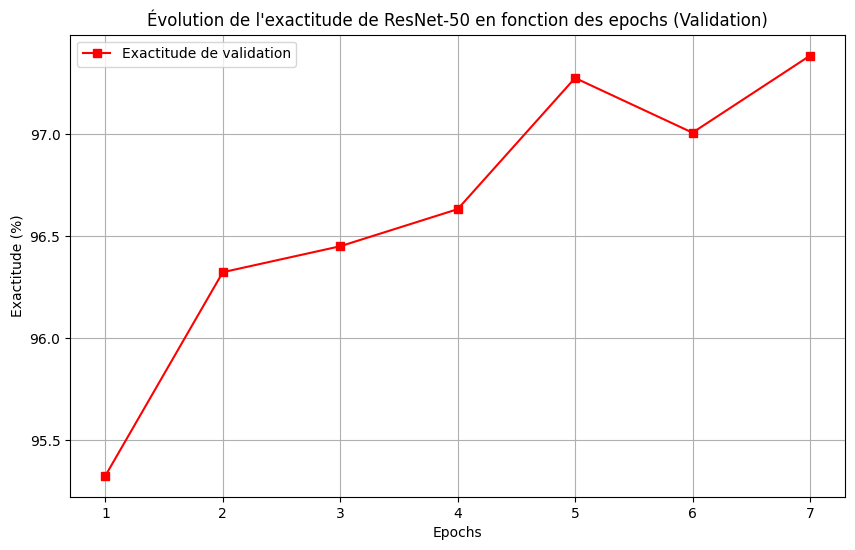

✓ Model saved with 97.38% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 171804 correct out of 176020


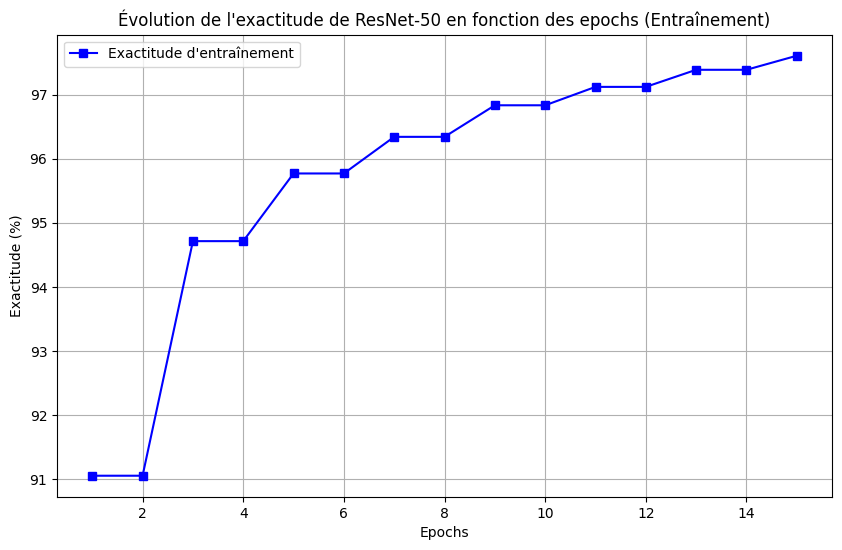

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.79% | Precision: 97.00% | Recall: 97.55% | F1: 0.9728


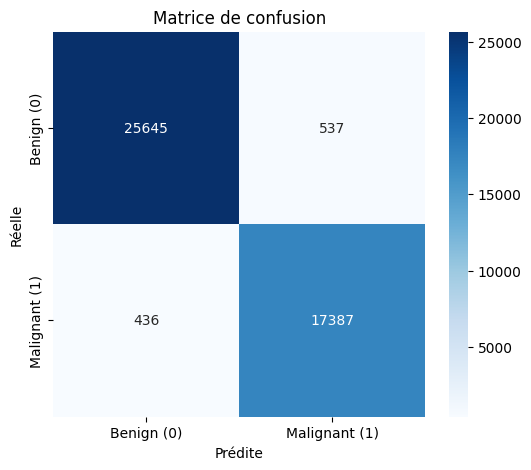

Epoch [8/15] Train Loss: 0.0675 | Train Acc: 97.60% | Val Acc: 97.79% 


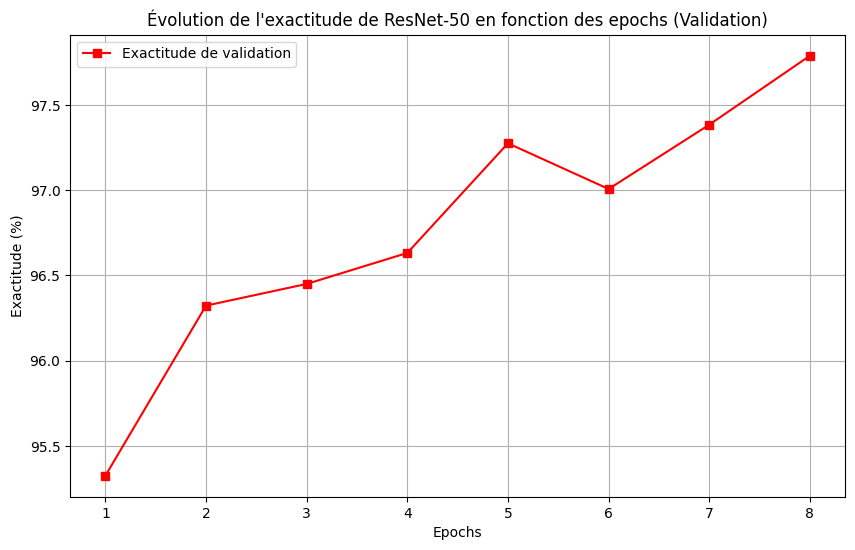

✓ Model saved with 97.79% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 172174 correct out of 176020


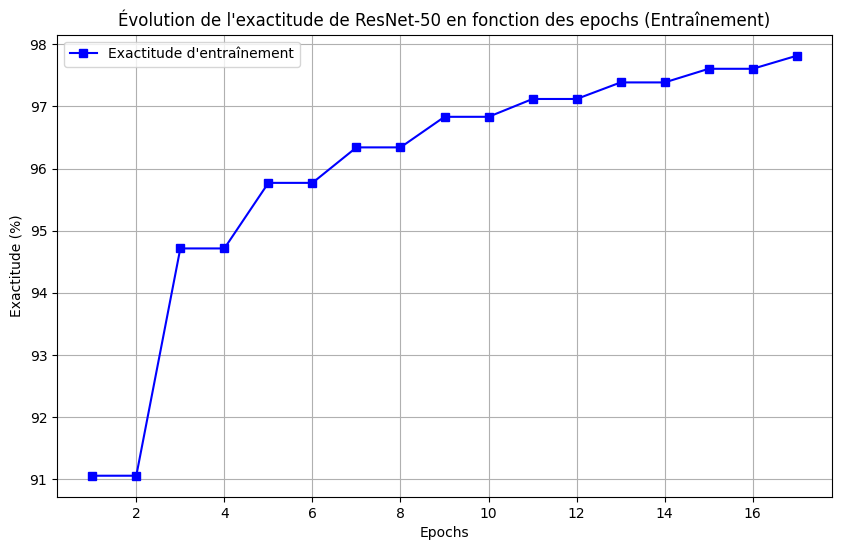

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.76% | Precision: 96.76% | Recall: 97.75% | F1: 0.9725


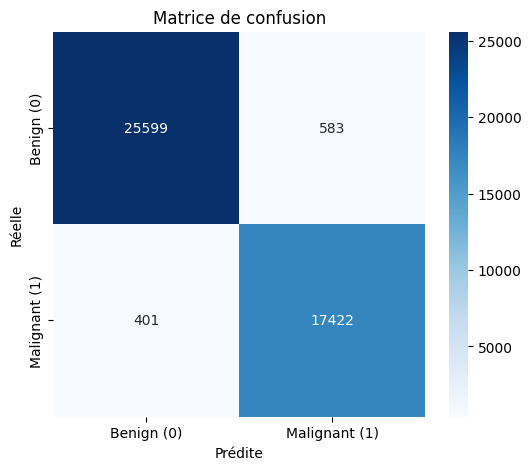

Epoch [9/15] Train Loss: 0.0622 | Train Acc: 97.82% | Val Acc: 97.76% 


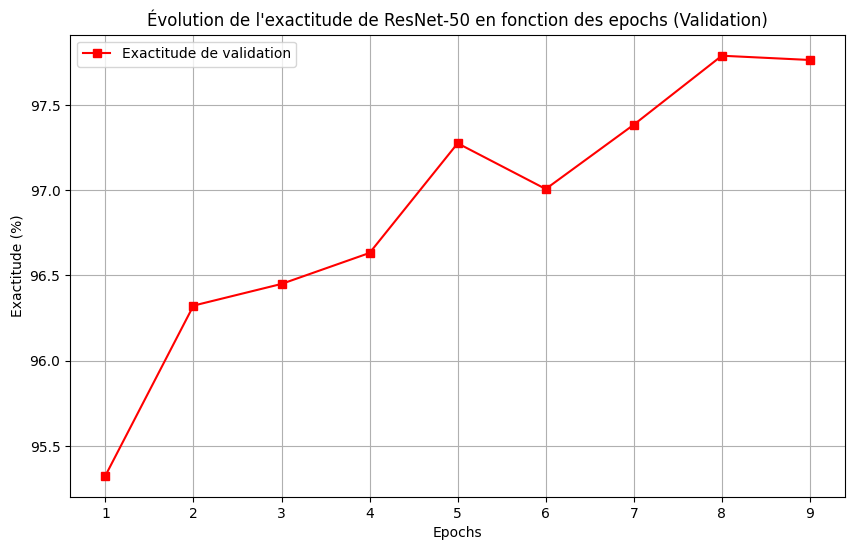

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 172426 correct out of 176020


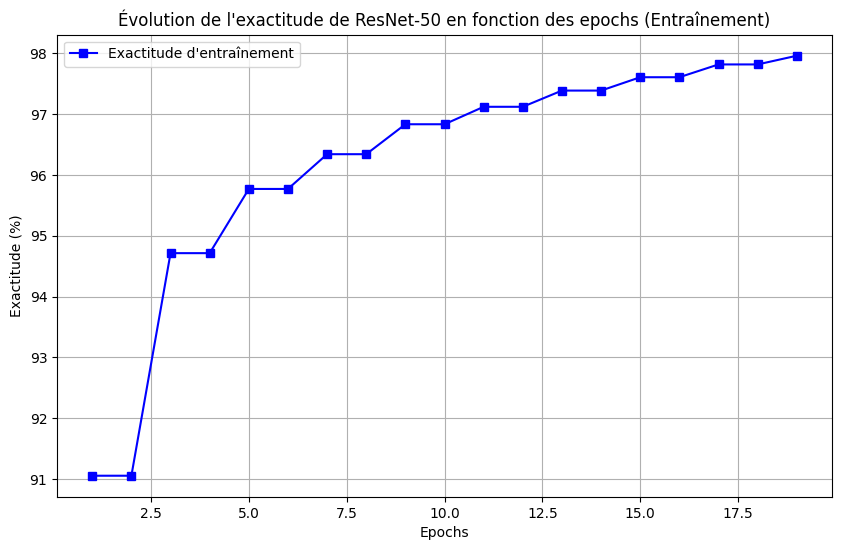

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.63% | Precision: 97.21% | Recall: 96.91% | F1: 0.9706


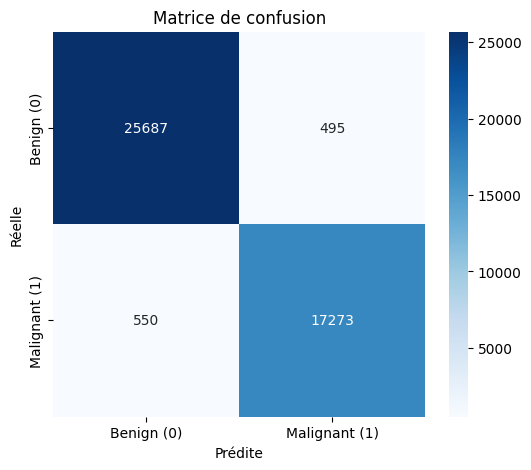

Epoch [10/15] Train Loss: 0.0571 | Train Acc: 97.96% | Val Acc: 97.63% 


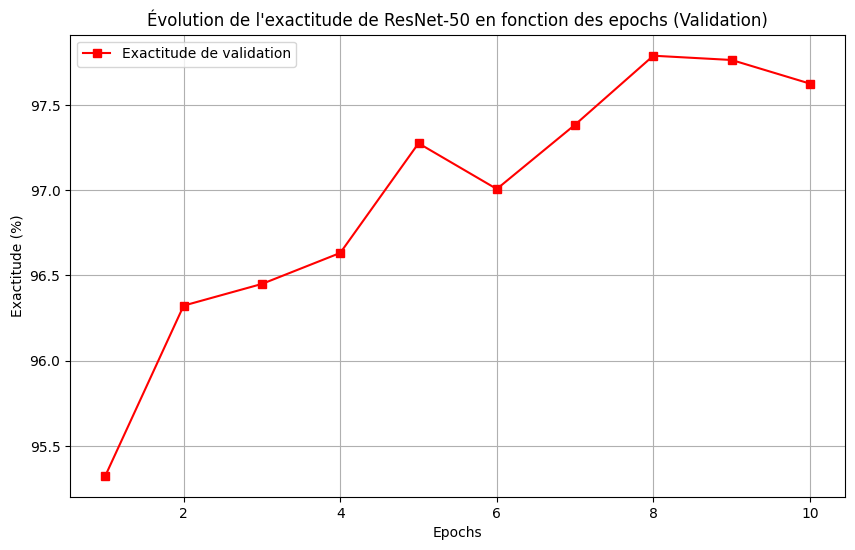

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 172629 correct out of 176020


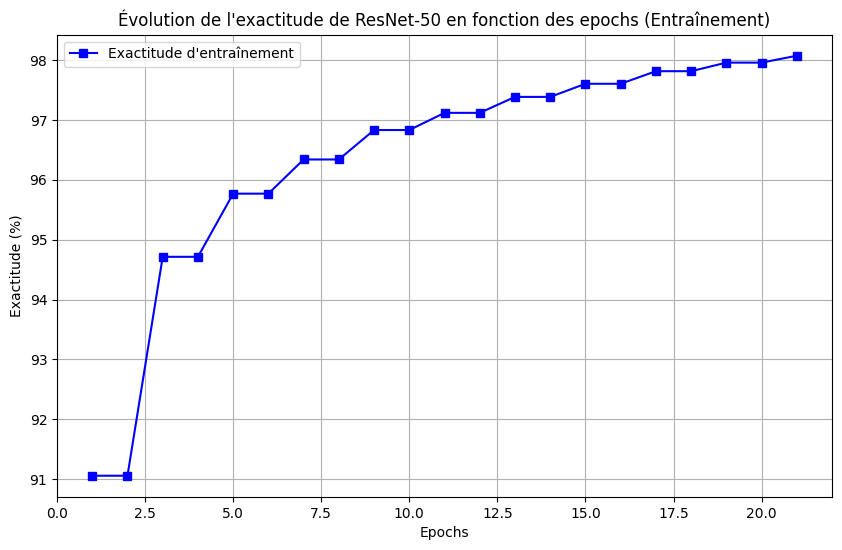

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.82% | Precision: 97.03% | Recall: 97.60% | F1: 0.9732


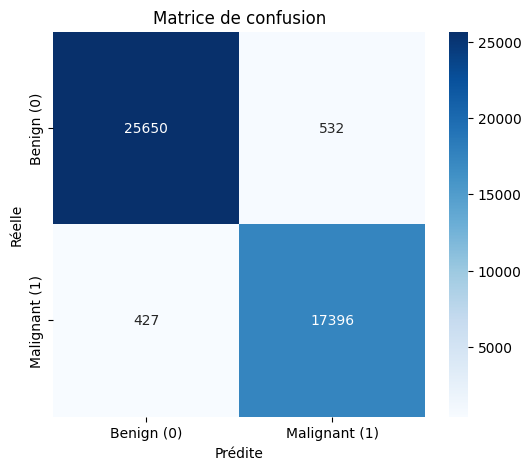

Epoch [11/15] Train Loss: 0.0539 | Train Acc: 98.07% | Val Acc: 97.82% 


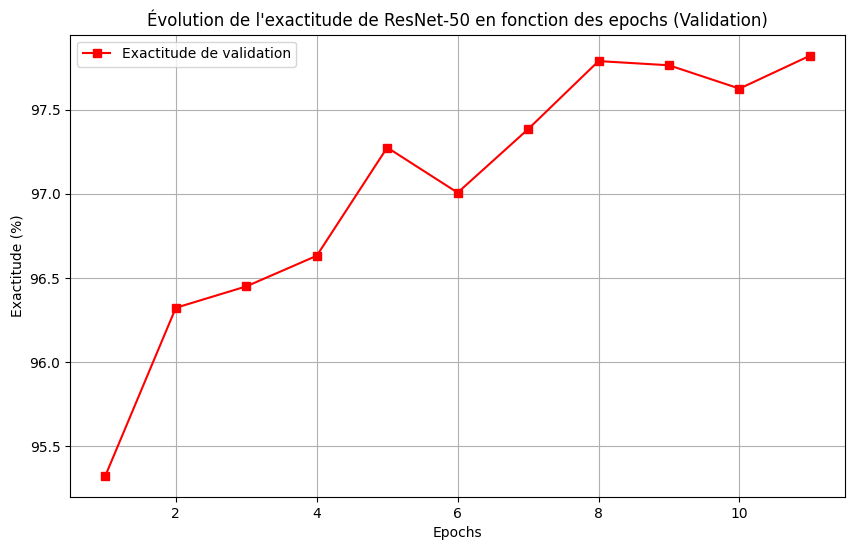

✓ Model saved with 97.82% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 172866 correct out of 176020


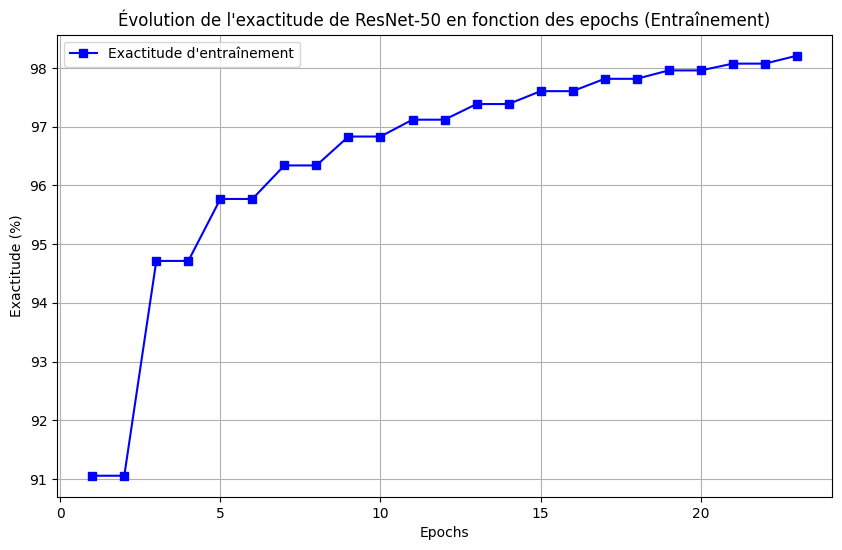

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.66% | Precision: 96.85% | Recall: 97.40% | F1: 0.9712


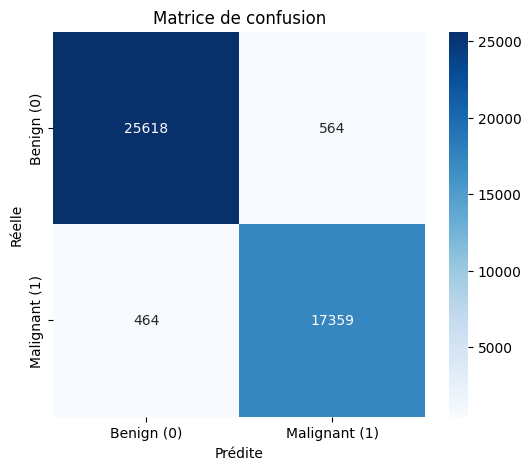

Epoch [12/15] Train Loss: 0.0504 | Train Acc: 98.21% | Val Acc: 97.66% 


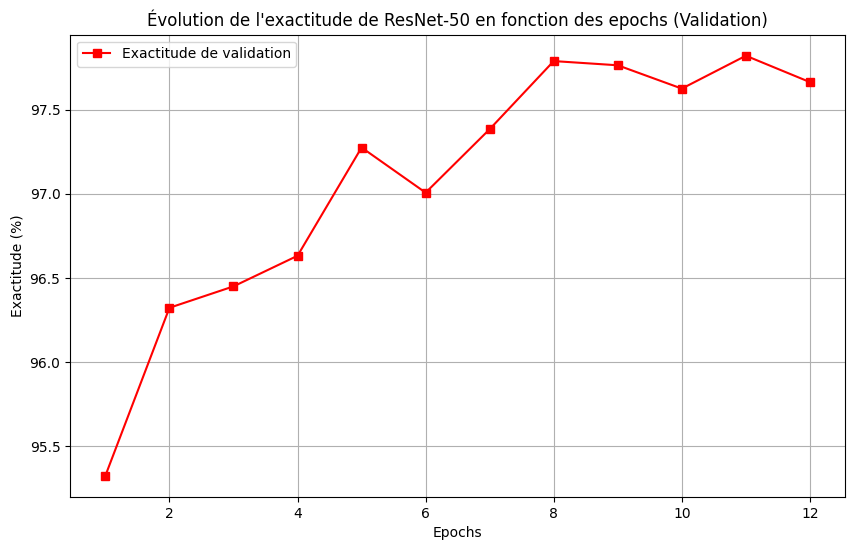

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 173072 correct out of 176020


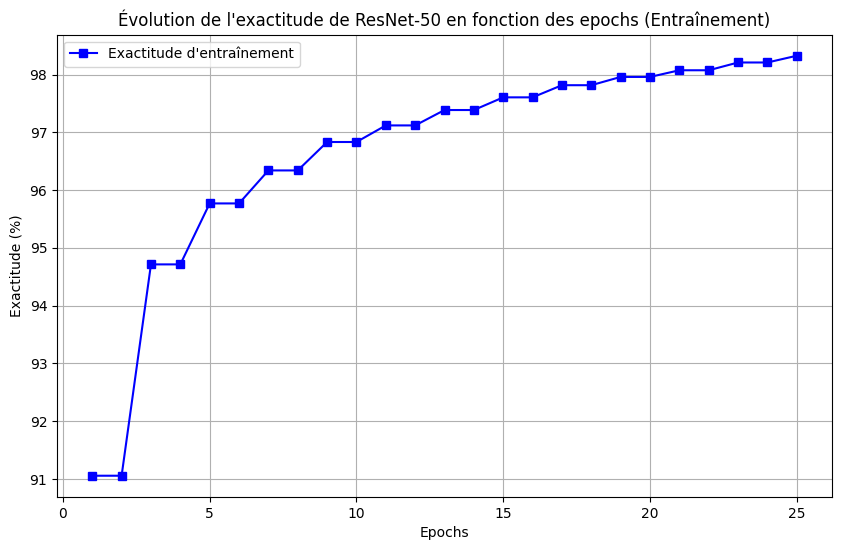

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.71% | Precision: 96.37% | Recall: 98.04% | F1: 0.9720


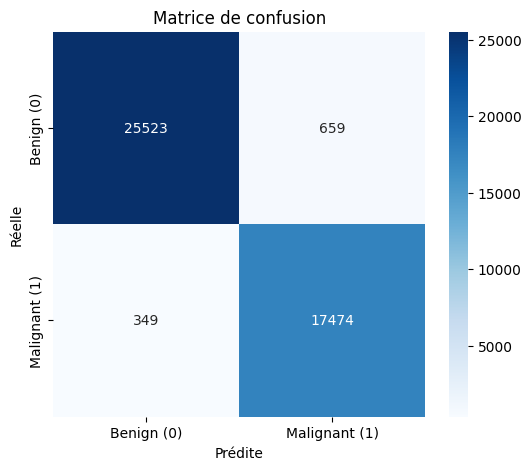

Epoch [13/15] Train Loss: 0.0464 | Train Acc: 98.33% | Val Acc: 97.71% 


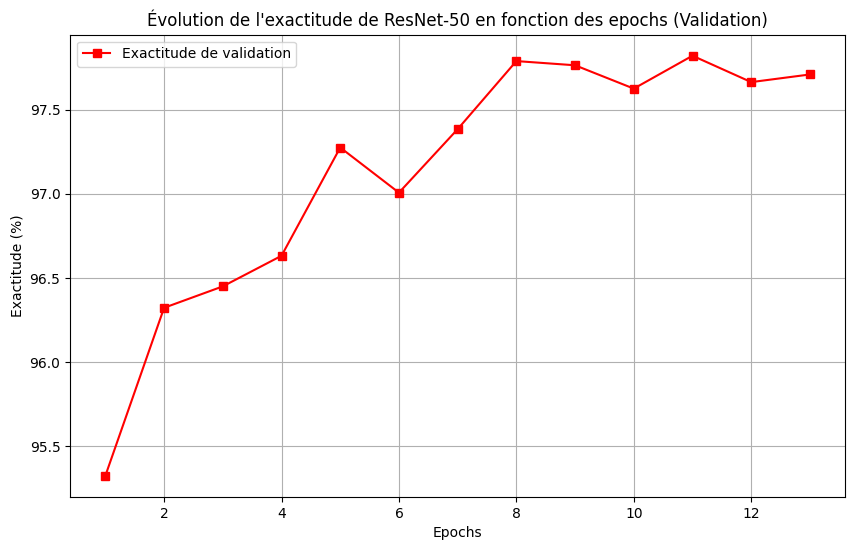

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 173267 correct out of 176020


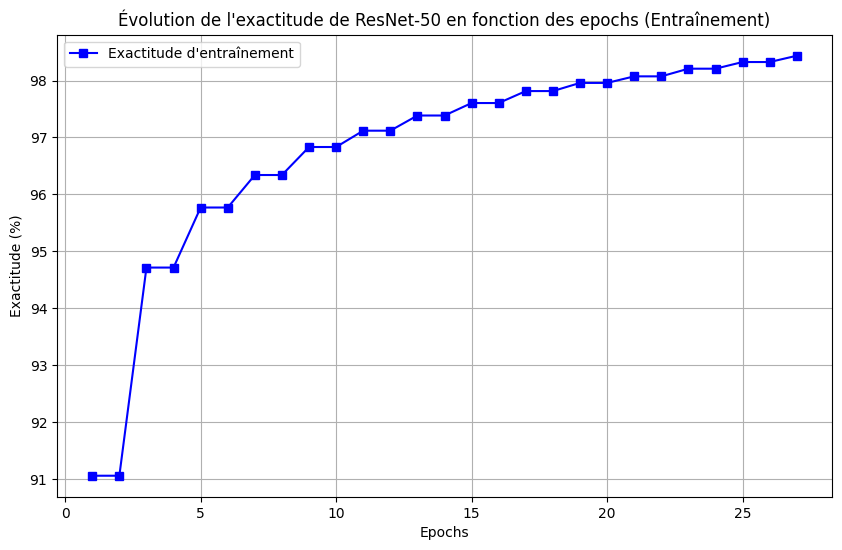

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.75% | Precision: 96.31% | Recall: 98.20% | F1: 0.9725


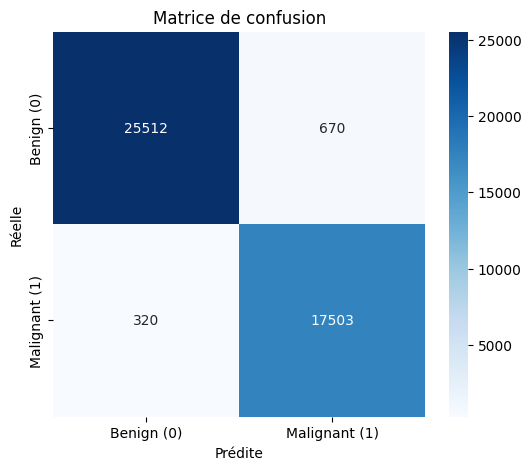

Epoch [14/15] Train Loss: 0.0438 | Train Acc: 98.44% | Val Acc: 97.75% 


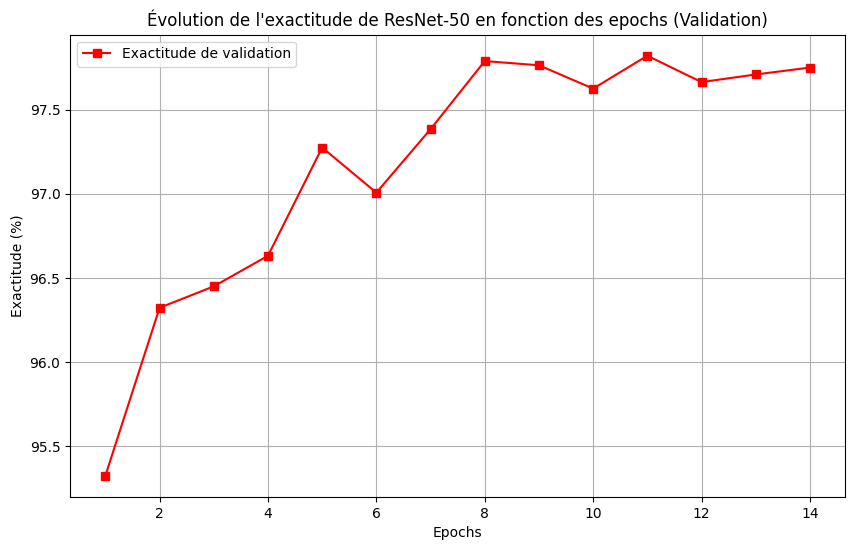

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 173489 correct out of 176020


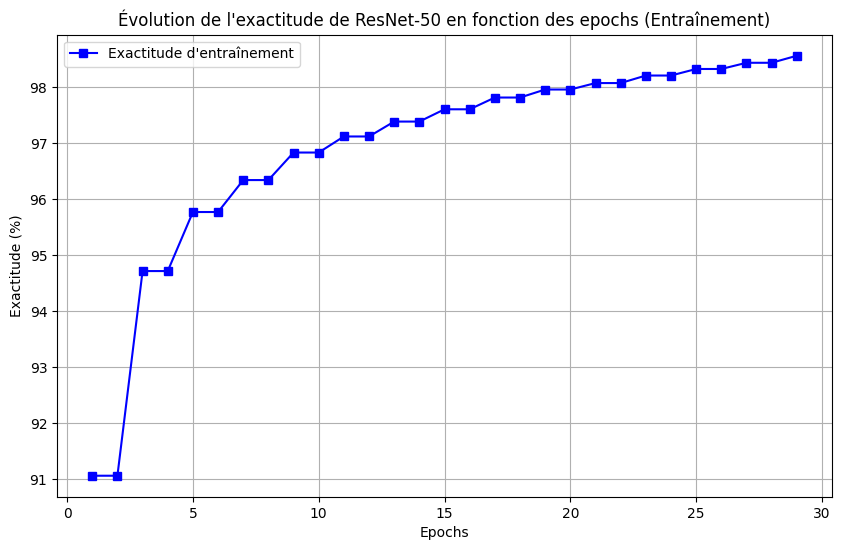

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 98.03% | Precision: 97.25% | Recall: 97.91% | F1: 0.9758


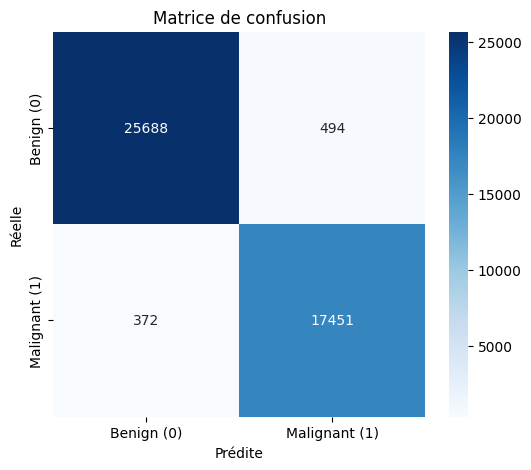

Epoch [15/15] Train Loss: 0.0407 | Train Acc: 98.56% | Val Acc: 98.03% 


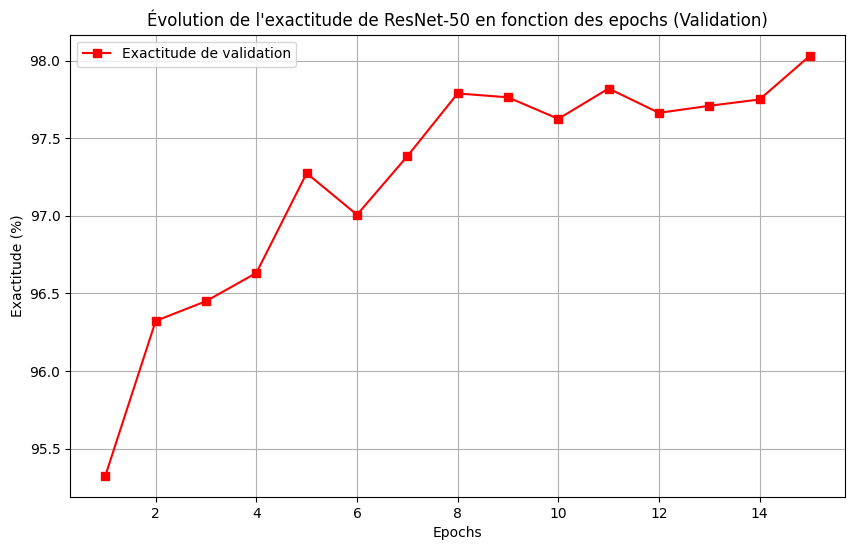

✓ Model saved with 98.03% accuracy


In [12]:
EPOCHS = 15  # increase later

train_acc_history = []
val_acc_history = []
best_val_acc = 0

for epoch in range(EPOCHS):
      
    train_loss, train_acc = train_one_epoch(model, train_loader)
    # Display training graph
    train_acc_history.append(train_acc * 100)
    plot_training_accuracy(train_acc_history)

    val_acc = validate(model, val_loader)
    
    # Save history for accuracy graph
    train_acc_history.append(train_acc * 100)
    val_acc_history.append(val_acc * 100)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc*100:.2f}% | "
          f"Val Acc: {val_acc*100:.2f}% ")
    
    # Display validation graph
    plot_validation_accuracy(val_acc_history)
    
    # Save model only if validation accuracy improves
    if val_acc > best_val_acc:
          best_val_acc = val_acc
          torch.save(model.state_dict(), "./claris_resnet-50.pth")
          print(f"✓ Model saved with {val_acc*100:.2f}% accuracy")
